In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

In [21]:
# Load dataset
qSales = pd.read_csv("qSales_2024.csv")
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [23]:
# Filter Target
target_sales = qSales.loc[qSales['tic']=='TGT'].copy()
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


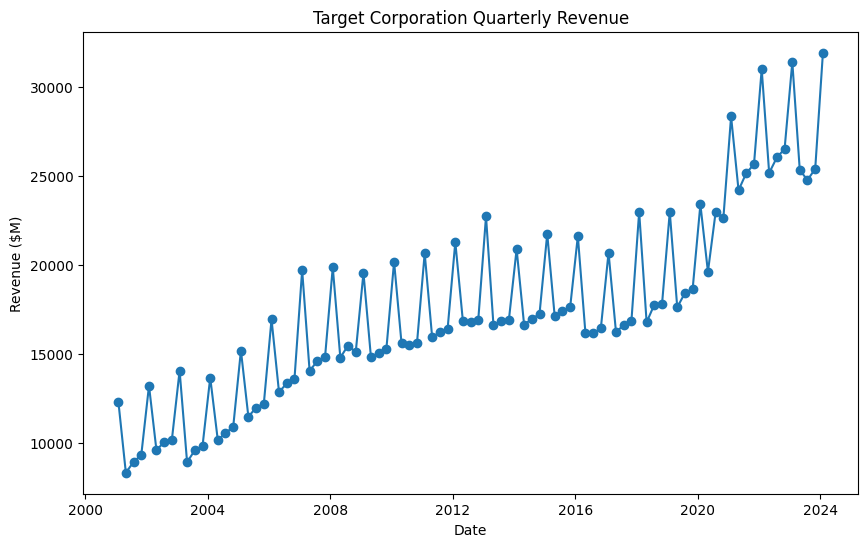

In [24]:
plt.figure(figsize=(10,6))
plt.title('Target Corporation Quarterly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($M)')
plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')
plt.show()

In [25]:
# Convert date
target["datadate"] = pd.to_datetime(target["datadate"])

In [26]:
# Create time variable
target = target.sort_values("datadate")
target_sales['time'] = range(1, len(target_sales) + 1)

In [27]:
# Create dummy variables
target_sales['holiday_q4'] = np.where(target_sales['fqtr'] == 4, 1, 0)
target_sales['post_holiday_q1'] = np.where(target_sales['fqtr'] == 1, 1, 0)

In [28]:
# Regression
x = target_sales.loc[:, ['time', 'holiday_q4', 'post_holiday_q1']]
x = sm.add_constant(x)
y = target_sales.loc[:, 'saleq']

model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     251.3
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           2.55e-43
Time:                        18:25:25   Log-Likelihood:                -824.72
No. Observations:                  93   AIC:                             1657.
Df Residuals:                      89   BIC:                             1668.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            8490.5060    413.481     20.534      0.000    7668.928    9312.084
time              168.7880      6.786     24.872      0.000     155.304     182.272
holiday_q4       4675.9175    442.279     10.572      0.000    3797.118    5554.717
post_holiday_q1  -386.3180    448.655     -0.861      0.392   -1277.786     505.150
==============================================================================
Omnibus:                        2.541   Durbin-Watson:                   0.152
Prob(Omnibus):                  0.281   Jarque-Bera (JB):                1.985
Skew:                          -0.205   Prob(JB):                        0.371
Kurtosis:                       2.413   Cond. No.                         170.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
# Predictions
target_sales['predicted'] = model.predict(x)

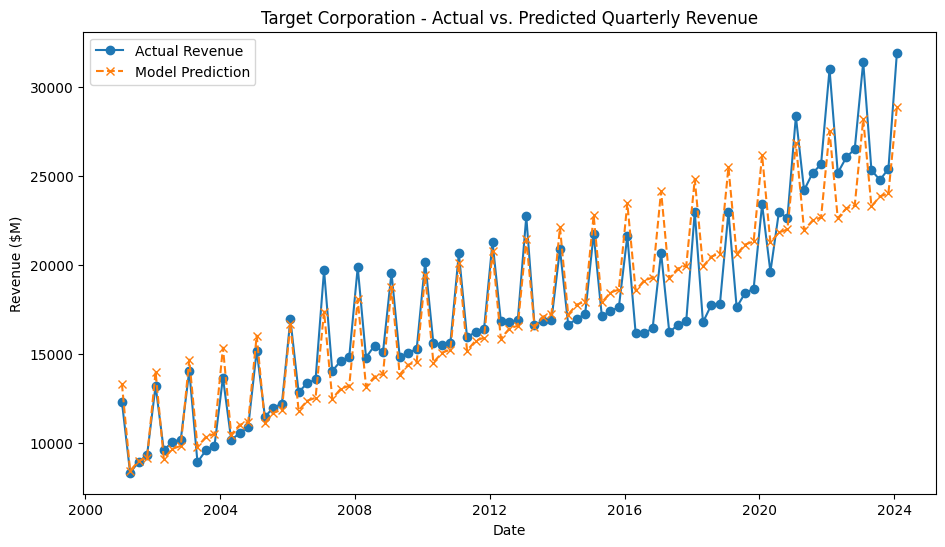

In [30]:
# Plot
plt.figure(figsize=(11,6))
plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o', label='Actual Revenue')
plt.plot(target_sales['datadate'], target_sales['predicted'], marker='x', linestyle='--', label='Model Prediction')
plt.title('Target Corporation - Actual vs. Predicted Quarterly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($M)')
plt.legend()
plt.show()

#Interpretation

The estimated model is approximately:

Revenue=8490.51+168.79(Time)+4675.92(Q4)−386.32(Q1)

- The model explains 89% of quarter-to-quarter variation in Target's revenue — a strong fit.

Time
- Positive coefficient (168.79)
- Target's quarterly revenue increases by approximately $169 million per quarter, holding the seasonal effects constant.

Q4 Dummy
- Positive coefficient (4675.92)
- Revenue is about $4.68 billion higher during Quarter 4 because of the holiday shopping season.

Q1 Dummy
- Small negative coefficient (−386.32)
- Revenue is slightly lower in Quarter 1 compared with the baseline quarters (Q2 and Q3), although this effect is not statistically significant.

Actual vs. Predicted

The chart shows the model tracking Target's seasonal sawtooth pattern and long-run growth closely, with the biggest gaps around the sharper post-2020 holiday peaks.

#Memo

To: Chapman Wealth Management

From: QuantFolio Solutions

Re: Target Corporation (TGT) — Quarterly Revenue Trend Analysis

##Overview

We built a quarterly time-series regression model of Target's revenue to assess the reliability and predictability of its top-line growth ahead of a potential investment. The model uses a linear time trend plus two dummy variables capturing Target's holiday retail seasonality.

**What the two dummy variables capture**

- Holiday quarter (Q4, Nov–Jan): isolates the predictable revenue spike from holiday sales, separate from the underlying growth trend.
- Post-holiday quarter (Q1, Feb–Apr): tests whether revenue pulls back in the quarter right after the holidays, once the holiday spike and trend are already controlled for.

##Model results
Fitted model: Revenue = 8,490.51 + 168.79 × Time + 4,675.92 × Holiday_Q4 − 386.32 × Post_Holiday_Q1. The model explains about 89% of quarter-to-quarter revenue variation (R² ≈ 0.89) — a strong, consistent pattern rather than erratic results. The time trend and holiday-quarter dummy are both statistically significant; the post-holiday dummy is not, meaning there's no unusual revenue cliff after the holidays beyond normal seasonal variation.

##Key insights for the investment decision

- Target's revenue growth is steady and highly predictable quarter to quarter.
- The business is meaningfully seasonal — a large, reliable share of incremental revenue is concentrated in the holiday quarter, which is normal and expected for a general-merchandise retailer, not a red flag.
- No evidence that holiday-quarter strength is simply pulling sales forward from the following quarter.
- Because the model fits history closely, it can reasonably support near-term revenue forecasting for valuation work, though it should be revisited if Target's business mix or seasonal patterns shift materially.